## Tomas Stankevičius, 2425049, Ver. 1

In [5]:
import os
import shutil
import random
import cv2
import numpy as np
import pandas as pd
import requests
import time
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive
from PIL import Image
from tqdm.notebook import tqdm
import warnings

from typing import List, Dict, Tuple, Optional

## Data Processing pipeline

### Approach: Data Processing & Class Balancing

**1. Class Selection and Mapping**
We focused on three distinct but related in context classes: `Pizza`, `Bottle`, and `Person`. These were selected to represent varying levels of geometric complexity and scale within the COCO dataset as well as to have some practical application.

**2. Balancing Strategy**
Standard COCO distributions are highly skewed (e.g., thousands of persons but fewer pizza instances). To prevent the model from developing a majority-class bias, we implemented a **Strictly Balanced Sampler**. By capping each class at 2,000 unique images, we ensure the network sees an equal number of training signals for each foreground object.

**3. Semantic Mask Generation**
COCO provides polygon-based annotations. We convert these into fixed-integer semantic masks where:
*   `0` = Background
*   `1-3` = Target Classes
During generation, we sort annotations by **area** (largest to smallest). This ensures that smaller objects are drawn 'on top' of larger ones in the final mask, preserving detail for small items like bottles that might be held by a person.

In [3]:
# Config
DRIVE_MOUNT_POINT = '/content/drive'
PROJECT_DIR = f'{DRIVE_MOUNT_POINT}/MyDrive/SegmentationProject'
DATASET_DIR = os.path.join(PROJECT_DIR, 'coco_dataset')
MASKS_DIR = os.path.join(PROJECT_DIR, 'semantic_masks')

os.makedirs(os.path.join(DATASET_DIR, 'train'), exist_ok=True)
os.makedirs(os.path.join(MASKS_DIR, 'train'), exist_ok=True)

# Our chosen classes and their new integer mappings
CLASS_MAP = {
    'background': 0,
    'pizza': 1,
    'bottle': 2,
    'person': 3
}

In [6]:
# Utility functions

def setup_environment(mount_point: str = DRIVE_MOUNT_POINT) -> None:
    """
    Mounts Google Drive safely, checking if it's already mounted first,
    and ensures project directories exist.
    """
    # If 'MyDrive' exists inside the mount point, it's already mounted safely.
    if not os.path.exists(os.path.join(mount_point, 'MyDrive')):
        drive.mount(mount_point)
    else:
        print(f"[INFO] Drive is already mounted at {mount_point}")

    os.makedirs(DATASET_DIR, exist_ok=True)
    os.makedirs(MASKS_DIR, exist_ok=True)
    print(f"[INFO] Environment setup complete. Data will be saved to: {PROJECT_DIR}")


def safe_mount_drive(sanity_check_path: str = None, force_remount: bool = True) -> bool:
    """
    Safely mounts Google Drive in Colab, handling corrupted 'zombie' mounts
    by purging leftover directories before attempting a fresh mount.

    Args:
        sanity_check_path: Optional path to verify after mounting.
        force_remount: Whether to force flush existing connections.

    Returns:
        bool: True if mounted (and verified), False otherwise.
    """
    print("[INFO] Initiating safe Google Drive mount sequence...")

    if force_remount:
        print("[INFO] Flushing existing connections...")
        drive.flush_and_unmount()

        drive_path = '/content/drive'
        if os.path.exists(drive_path):
            try:
                shutil.rmtree(drive_path)
            except OSError as e:
                print(f"[WARNING] Could not purge old drive directory: {e}")

    try:
        print("[INFO] Mounting Google Drive...")
        drive.mount('/content/drive', force_remount=force_remount)
    except Exception as e:
        print(f"[ERROR] Fatal error during mount: {e}")
        return False

    # Perform the sanity check if a path was provided
    if sanity_check_path:
        if os.path.exists(sanity_check_path):
            file_count = len(os.listdir(sanity_check_path))
            print(f"\n[SUCCESS] Mount verified! Found {file_count} items at: {sanity_check_path}")
            return True
        else:
            print(f"\n[ERROR] Mounted successfully, but could NOT find: {sanity_check_path}")
            return False

    return True


def transfer_to_local_ssd(source_dir: str, dest_dir: str) -> str:
    """
    Copies a directory from slow network storage to the high-speed local Colab NVMe SSD.

    Args:
        source_dir: The path on Google Drive.
        dest_dir: The target path on the local Colab instance.

    Returns:
        str: The path to the new local directory.
    """
    if not os.path.exists(source_dir):
        raise FileNotFoundError(f"[ERROR] Source directory missing: {source_dir}")

    print(f"[INFO] Transferring data to local SSD...")
    print(f"       Source: {source_dir}")
    print(f"       Target: {dest_dir}")

    start_time = time.time()

    # dirs_exist_ok=True prevents crashes if you run the cell twice
    shutil.copytree(source_dir, dest_dir, dirs_exist_ok=True)

    elapsed = time.time() - start_time
    print(f"[SUCCESS] Transfer complete in {elapsed:.2f} seconds.")

    return dest_dir


def download_coco_annotations() -> str:
    """Downloads the COCO 2017 training annotations JSON (approx 800MB)."""
    ann_dir = '/content/annotations'
    ann_file = os.path.join(ann_dir, 'instances_train2017.json')

    if not os.path.exists(ann_file):
        print("[INFO] Downloading COCO 2017 Annotations (this takes a minute)...")
        os.makedirs(ann_dir, exist_ok=True)
        # Download and unzip directly via command line for speed
        !wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip -O /content/annotations.zip
        !unzip -q /content/annotations.zip -d /content/
        !rm /content/annotations.zip

    return ann_file


def generate_balanced_coco_dataset(samples_per_class: int = 1500) -> None:
    """Queries COCO and downloads a strictly balanced number of images per class."""
    ann_file = download_coco_annotations()
    print("[INFO] Loading COCO API...")
    from pycocotools.coco import COCO
    import requests
    coco = COCO(ann_file)

    target_classes = ['pizza', 'bottle', 'person']
    selected_img_ids = set()

    print("\n[INFO] Balancing dataset selection...")
    for cat_name in target_classes:
        cat_id = coco.getCatIds(catNms=[cat_name])[0]
        img_ids = coco.getImgIds(catIds=[cat_id])

        # Shuffle to get a random assortment
        np.random.shuffle(img_ids)

        added_for_this_class = 0
        for img_id in img_ids:
            if added_for_this_class >= samples_per_class:
                break
            # Ensure we don't accidentally count an image twice if it has multiple classes
            if img_id not in selected_img_ids:
                selected_img_ids.add(img_id)
                added_for_this_class += 1

        print(f"[INFO] Successfully selected {added_for_this_class} unique images for '{cat_name}'.")

    selected_img_ids = list(selected_img_ids)
    print(f"\n[INFO] Found {len(selected_img_ids)} strictly balanced images. Starting pipeline...")

    saved_count = 0
    # Get all category IDs for our map
    cat_ids = coco.getCatIds(catNms=target_classes)

    for img_id in selected_img_ids:
        img_info = coco.loadImgs(img_id)[0]

        # Download the original JPG
        img_url = img_info['coco_url']
        img_filename = img_info['file_name']
        img_path = os.path.join(DATASET_DIR, 'train', img_filename)

        if not os.path.exists(img_path):
            img_data = requests.get(img_url).content
            with open(img_path, 'wb') as handler:
                handler.write(img_data)

        # Create the blank semantic mask
        semantic_mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

        # Get all annotations for this specific image
        ann_ids = coco.getAnnIds(imgIds=img_info['id'], catIds=cat_ids, iscrowd=False)
        annotations = coco.loadAnns(ann_ids)

        # Sort by area (draw largest first, small objects on top)
        annotations = sorted(annotations, key=lambda a: a['area'], reverse=True)

        # Draw the pixel-perfect polygons
        for ann in annotations:
            cat_name = coco.loadCats(ann['category_id'])[0]['name']
            class_idx = CLASS_MAP[cat_name]

            # Convert polygon to boolean mask
            binary_mask = coco.annToMask(ann)

            # Apply to main mask
            semantic_mask[binary_mask == 1] = class_idx

        # Save the Mask as PNG
        mask_filename = img_filename.replace('.jpg', '.png')
        mask_path = os.path.join(MASKS_DIR, 'train', mask_filename)
        cv2.imwrite(mask_path, semantic_mask)

        saved_count += 1
        if saved_count % 200 == 0:
            print(f"Processed {saved_count} / {len(selected_img_ids)} images...")

    print("[SUCCESS] Balanced COCO Dataset pipeline complete!")


def create_split_directories() -> None:
    """Ensures that train, val, and test directories exist for both images and masks."""
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(DATASET_DIR, split), exist_ok=True)
        os.makedirs(os.path.join(MASKS_DIR, split), exist_ok=True)


def move_split_files(
    file_list: List[str],
    target_split: str,
    source_mask_dir: str,
    source_img_dir: str
) -> None:
    """
    Physically moves a list of mask files and their corresponding images
    from the source directory to the target split directory.

    Args:
        file_list (List[str]): List of mask filenames (e.g., ['0001.png', ...]).
        target_split (str): The target split directory name ('val' or 'test').
        source_mask_dir (str): Path to the directory currently containing the masks.
        source_img_dir (str): Path to the directory currently containing the images.
    """
    if target_split == 'train':
        return  # Files are already in the train folder!

    target_mask_dir = os.path.join(MASKS_DIR, target_split)
    target_img_dir = os.path.join(DATASET_DIR, target_split)

    for mask_name in file_list:
        img_name = mask_name.replace('.png', '.jpg')

        # Source paths
        old_mask_path = os.path.join(source_mask_dir, mask_name)
        old_img_path = os.path.join(source_img_dir, img_name)

        # Target paths
        new_mask_path = os.path.join(target_mask_dir, mask_name)
        new_img_path = os.path.join(target_img_dir, img_name)

        # Move files safely
        if os.path.exists(old_mask_path) and os.path.exists(old_img_path):
            shutil.move(old_mask_path, new_mask_path)
            shutil.move(old_img_path, new_img_path)


def partition_dataset(train_ratio: float = 0.80, val_ratio: float = 0.10) -> None:
    """
    Reads all files currently in the 'train' folder, randomly shuffles them,
    and moves them into 'val' and 'test' folders based on the specified ratios.
    """
    create_split_directories()

    # We look at the masks directory as our source of truth
    source_mask_dir = os.path.join(MASKS_DIR, 'train')
    source_img_dir = os.path.join(DATASET_DIR, 'train')

    # Get all .png mask filenames
    all_masks = [f for f in os.listdir(source_mask_dir) if f.endswith('.png')]

    if not all_masks:
        print("[WARNING] No masks found in the train directory. Has it already been split?")
        return

    # Randomly shuffle the dataset to ensure a fair distribution of classes
    random.seed(42)  # Seed for reproducibility
    random.shuffle(all_masks)

    total_files = len(all_masks)
    train_end = int(total_files * train_ratio)
    val_end = train_end + int(total_files * val_ratio)

    # Slice the shuffled list
    train_files = all_masks[:train_end]
    val_files = all_masks[train_end:val_end]
    test_files = all_masks[val_end:]

    print(f"[INFO] Total images found: {total_files}")
    print(f"[INFO] Distributing: {len(train_files)} Train | {len(val_files)} Val | {len(test_files)} Test")

    # Execute the moves using the newly decoupled function
    move_split_files(val_files, 'val', source_mask_dir, source_img_dir)
    move_split_files(test_files, 'test', source_mask_dir, source_img_dir)

    print("[SUCCESS] Dataset successfully partitioned and saved to Google Drive!")

In [ ]:
setup_environment()
generate_balanced_coco_dataset(samples_per_class=2000)

[INFO] Drive is already mounted at /content/drive
[INFO] Environment setup complete. Data will be saved to: /content/drive/MyDrive/SegmentationProject
[INFO] Loading COCO API...
loading annotations into memory...
Done (t=29.33s)
creating index...
index created!

[INFO] Balancing dataset selection...
[INFO] Successfully selected 2000 unique images for 'pizza'.
[INFO] Successfully selected 2000 unique images for 'bottle'.
[INFO] Successfully selected 2000 unique images for 'person'.

[INFO] Found 6000 strictly balanced images. Starting pipeline...
Processed 200 / 6000 images...
Processed 400 / 6000 images...
Processed 600 / 6000 images...
Processed 800 / 6000 images...
Processed 1000 / 6000 images...
Processed 1200 / 6000 images...
Processed 1400 / 6000 images...
Processed 1600 / 6000 images...
Processed 1800 / 6000 images...
Processed 2000 / 6000 images...
Processed 2200 / 6000 images...
Processed 2400 / 6000 images...
Processed 2600 / 6000 images...
Processed 2800 / 6000 images...
Proc

In [ ]:
partition_dataset()

[INFO] Total images found: 6000
[INFO] Distributing: 4800 Train | 600 Val | 600 Test
[SUCCESS] Dataset successfully partitioned and saved to Google Drive!


## Data analysis

### Approach: Data Analysis & Uncertainty Visualization

**1. Statistical Distribution Analysis**
To ensure our balancing strategy was successful, we scan every mask across all splits (Train/Val/Test). We calculate:
*   **Pixel-Level Distribution:** Identifies extreme class imbalances (e.g., the rarity of the 'Bottle' class compared to 'Background').
*   **Image Presence %:** Confirms that each class appears in the expected number of images.

**2. Visual Ground-Truth Verification**
We randomly sample images from each target class to verify that the polygon-to-mask conversion correctly handled overlapping objects and preserved smaller details like bottles held by persons.

In [13]:
ID_TO_NAME: Dict[int, str] = {
    0: 'Background',
    1: 'Pizza',
    2: 'Bottle',
    3: 'Person'
}

def analyze_dataset_statistics(splits: list = ['train', 'val', 'test']) -> None:
    """
    Scans the generated semantic masks to calculate image-level and pixel-level
    class distributions across all dataset splits.
    """
    print("[INFO] Starting Dataset Allocation Analysis...")

    # Dynamically initialize the stats dictionary using our ID_TO_NAME keys
    # This prevents hardcoding errors and makes the script infinitely reusable
    stats = {
        split: {
            'total_images': 0,
            'pixels': {k: 0 for k in ID_TO_NAME.keys()},
            'images_with_class': {k: 0 for k in ID_TO_NAME.keys()}
        } for split in splits
    }

    for split in splits:
        split_dir = os.path.join(MASKS_DIR, split)
        if not os.path.exists(split_dir):
            print(f"[WARNING] Directory {split_dir} not found. Skipping.")
            continue

        masks = [f for f in os.listdir(split_dir) if f.endswith('.png')]
        stats[split]['total_images'] = len(masks)

        if len(masks) == 0:
            continue

        print(f"\nAnalyzing {split.upper()} split ({len(masks)} images)...")

        for mask_name in tqdm(masks):
            mask_path = os.path.join(split_dir, mask_name)
            # Load mask in grayscale (returns 2D array of integers)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if mask is None:
                continue

            # Count unique classes present in this specific image
            unique_classes, counts = np.unique(mask, return_counts=True)

            for cls_idx, count in zip(unique_classes, counts):
                if cls_idx in ID_TO_NAME:
                    # Add to absolute pixel count
                    stats[split]['pixels'][cls_idx] += count
                    # Log that this image contains this class
                    stats[split]['images_with_class'][cls_idx] += 1

    for split in splits:
        if stats[split]['total_images'] == 0:
            continue

        print(f"\n{'='*40}")
        print(f"SPLIT: {split.upper()} | Total Images: {stats[split]['total_images']}")
        print(f"{'='*40}")

        total_pixels = sum(stats[split]['pixels'].values())

        # Prepare data for DataFrame
        report_data = []
        for cls_idx, cls_name in ID_TO_NAME.items():
            px_count = stats[split]['pixels'][cls_idx]
            img_count = stats[split]['images_with_class'][cls_idx]

            px_pct = (px_count / total_pixels) * 100 if total_pixels > 0 else 0
            img_pct = (img_count / stats[split]['total_images']) * 100

            report_data.append({
                'Class': cls_name,
                'Total Pixels': f"{px_count:,}",
                'Pixel %': f"{px_pct:.2f}%",
                'Images Containing Class': f"{img_count:,}",
                'Image Presence %': f"{img_pct:.1f}%"
            })

        df = pd.DataFrame(report_data)
        display(df)

        # Plotting Pixel Distribution (Log Scale)
        classes = list(ID_TO_NAME.values())
        pixel_counts = [stats[split]['pixels'][i] for i in ID_TO_NAME.keys()]

        plt.figure(figsize=(10, 4))
        bars = plt.bar(classes, pixel_counts, color=['#333333', '#FF2A2A', '#0080FF', '#00FF00'])
        plt.yscale('log') # Log scale prevents background from hiding the foreground bars
        plt.title(f"{split.upper()} Split: Pixel Distribution (Log Scale)", fontsize=14)
        plt.ylabel("Total Pixels (Log)")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()


def visualize_dataset_samples(
    image_dir: str,
    mask_dir: str,
    class_map: Dict[str, int],
    num_samples_per_class: int = 3
) -> None:
    """
    Scans the dataset and visualizes a specific number of random samples for each class.
    Displays the original image, semantic mask, and alpha-blended overlay.

    Args:
        image_dir (str): Path to the directory containing original images (.jpg).
        mask_dir (str): Path to the directory containing semantic masks (.png).
        class_map (Dict[str, int]): Dictionary mapping class names to integer labels.
        num_samples_per_class (int): Number of images to find and display per foreground class.
    """
    mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.png')]

    if not mask_files:
        print("[ERROR] No masks found in the specified directory.")
        return

    # Ignore background (0) for finding targeted class samples
    target_classes = {v: k for k, v in class_map.items() if v != 0}
    class_roster: Dict[int, List[str]] = {cls_idx: [] for cls_idx in target_classes.keys()}
    used_masks = set()

    print(f"[INFO] Scanning for {num_samples_per_class} images per class...")
    random.seed(42) # Ensure we get different but reproducible random samples
    random.shuffle(mask_files)

    for mask_name in mask_files:
        mask_path = os.path.join(mask_dir, mask_name)
        try:
            # Fast read just to find present classes
            mask_arr = np.array(Image.open(mask_path).convert("L"))
            present_classes = np.unique(mask_arr)
        except Exception:
            continue

        # Assign image to the first target class it contains that still needs samples
        for cls_idx in present_classes:
            if cls_idx in class_roster and len(class_roster[cls_idx]) < num_samples_per_class:
                if mask_name not in used_masks:
                    class_roster[cls_idx].append(mask_name)
                    used_masks.add(mask_name)
                    break # Move to next image to avoid visual duplicates across classes

        # Break out of loop early if all class quotas are filled!
        if all(len(samples) == num_samples_per_class for samples in class_roster.values()):
            break

    # Flatten the roster into a single ordered list for plotting
    selected_masks: List[Tuple[str, str]] = [] # stores (mask_name, target_class_name)
    for cls_idx, masks in class_roster.items():
        cls_name = target_classes[cls_idx]
        for m in masks:
            selected_masks.append((m, cls_name))

    if not selected_masks:
        print("[WARNING] Could not find any target classes in the scanned masks.")
        return

    colors = ['#000000', '#FF2A2A', '#0080FF', '#00FF00']
    cmap = ListedColormap(colors[:len(class_map)])

    fig, axes = plt.subplots(len(selected_masks), 3, figsize=(15, 4.5 * len(selected_masks)))

    if len(selected_masks) == 1:
        axes = [axes]

    for idx, (mask_filename, target_class) in enumerate(selected_masks):
        image_filename = mask_filename.replace('.png', '.jpg')
        img_path = os.path.join(image_dir, image_filename)
        mask_path = os.path.join(mask_dir, mask_filename)

        try:
            image = np.array(Image.open(img_path).convert("RGB"))
            mask = np.array(Image.open(mask_path).convert("L"))
        except FileNotFoundError:
            continue

        axes[idx][0].imshow(image)
        axes[idx][0].set_title(f"Targeting: {target_class.upper()}\nOriginal: {image_filename}", fontsize=12)
        axes[idx][0].axis('off')

        axes[idx][1].imshow(mask, cmap=cmap, vmin=0, vmax=len(class_map)-1)
        axes[idx][1].set_title("Semantic Mask", fontsize=12)
        axes[idx][1].axis('off')

        axes[idx][2].imshow(image)
        axes[idx][2].imshow(mask, cmap=cmap, vmin=0, vmax=len(class_map)-1, alpha=0.5)
        axes[idx][2].set_title("Alpha Overlay", fontsize=12)
        axes[idx][2].axis('off')

    # Add Global Legend
    legend_patches = [mpatches.Patch(color=colors[v], label=k) for k, v in class_map.items()]
    fig.legend(handles=legend_patches, loc='lower center', ncol=len(class_map), fontsize=14)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.05 if len(selected_masks) > 3 else 0.1)
    plt.show()

In [ ]:
DRIVE_VAL_DIR = '/content/drive/MyDrive/SegmentationProject/semantic_masks/val'
is_mounted = safe_mount_drive(sanity_check_path=DRIVE_VAL_DIR)

[INFO] Initiating safe Google Drive mount sequence...
[INFO] Flushing existing connections...
Drive not mounted, so nothing to flush and unmount.
[INFO] Mounting Google Drive...
Mounted at /content/drive

[SUCCESS] Mount verified! Found 600 items at: /content/drive/MyDrive/SegmentationProject/semantic_masks/val


[INFO] Starting Dataset Allocation Analysis...

Analyzing TRAIN split (4800 images)...


  0%|          | 0/4800 [00:00<?, ?it/s]


Analyzing VAL split (600 images)...


  0%|          | 0/600 [00:00<?, ?it/s]


Analyzing TEST split (600 images)...


  0%|          | 0/600 [00:00<?, ?it/s]


SPLIT: TRAIN | Total Images: 4800


,Class,Total Pixels,Pixel %,Images Containing Class,Image Presence %
0,Background,"1,018,547,812",75.44%,"4,800",100.0%
1,Pizza,"135,162,670",10.01%,"1,697",35.4%
2,Bottle,"14,855,248",1.10%,"2,016",42.0%
3,Person,"181,540,700",13.45%,"3,272",68.2%


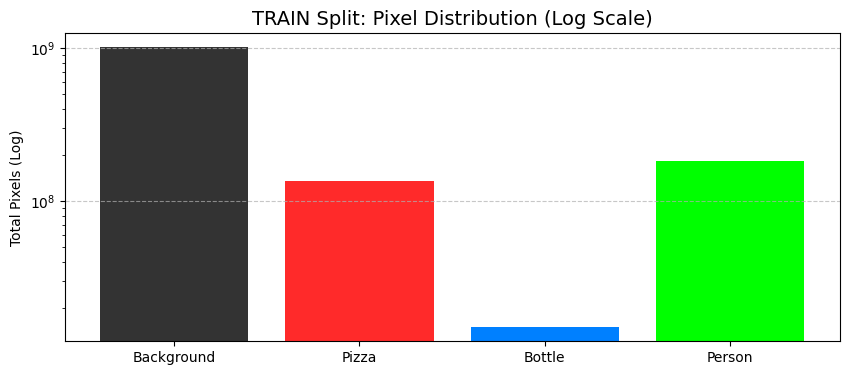


SPLIT: VAL | Total Images: 600


,Class,Total Pixels,Pixel %,Images Containing Class,Image Presence %
0,Background,"126,733,048",74.38%,600,100.0%
1,Pizza,"19,507,764",11.45%,209,34.8%
2,Bottle,"1,831,093",1.07%,233,38.8%
3,Person,"22,320,326",13.10%,400,66.7%


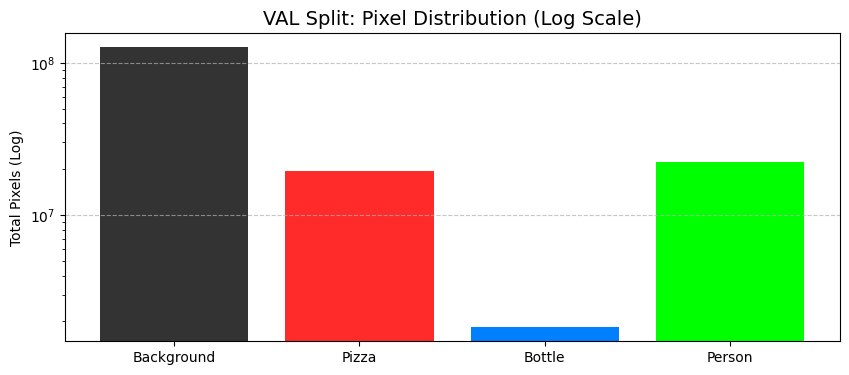


SPLIT: TEST | Total Images: 600


,Class,Total Pixels,Pixel %,Images Containing Class,Image Presence %
0,Background,"131,654,616",77.21%,600,100.0%
1,Pizza,"16,273,149",9.54%,195,32.5%
2,Bottle,"1,779,873",1.04%,256,42.7%
3,Person,"20,812,493",12.21%,399,66.5%


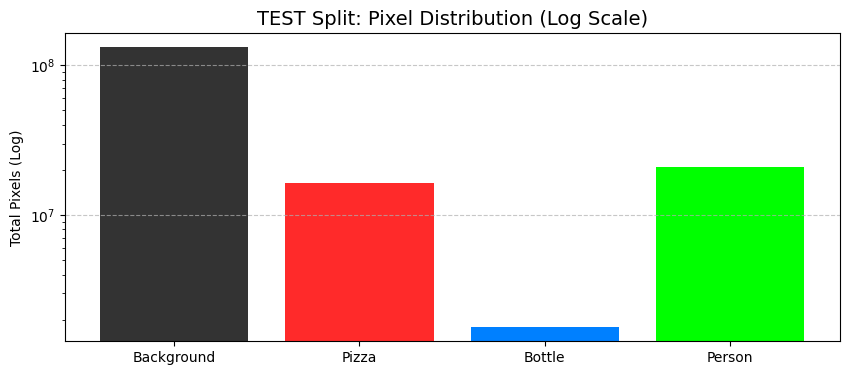

In [ ]:
analyze_dataset_statistics()

In [ ]:
train_images = os.path.join(DATASET_DIR, "train")
train_masks = os.path.join(MASKS_DIR, "train")

visualize_dataset_samples(
    image_dir=train_images,
    mask_dir=train_masks,
    class_map=CLASS_MAP,
    num_samples_per_class=3
)

Output hidden; open in https://colab.research.google.com to view.

## Model Creation & Training

### Approach: Model Architecture & Loss Function

**1. U-Net Architecture**
We utilized a classic **U-Net** structure. The choice of U-Net is driven by the 'Skip Connections' which concatenate high-resolution features from the encoder directly to the decoder. This is crucial for semantic segmentation because it allows the model to localize boundaries precisely while maintaining global context.

**2. Combined Loss (Dice + Cross-Entropy)**
Training a segmentation model from scratch often suffers from pixel-imbalance (background pixels usually outnumber foreground pixels 100:1).
*   **Weighted Cross-Entropy:** Penalizes pixel-wise classification errors, with higher weights assigned to rarer classes (Bottle).
*   **Dice Loss:** Measures the overlap (Intersection over Union) between predicted and ground truth. It is relatively invariant to the number of background pixels, focusing strictly on object shape.

**3. Training Stability**
We use **Kaiming Normal Initialization** for weights and **Batch Normalization** as per U-Net paper instead of PyTorch default **Kaiman Uniform Initializtion** after every convolution to prevent vanishing gradients, allowing for a higher initial learning rate.

In [ ]:
!pip install torchinfo pytorch-lightning

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import pytorch_lightning as pl
import torchmetrics
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

pl.seed_everything(42, workers=True)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [ ]:
def initialize_weights(model):
    """
    Applies Kaiming Normal initialization to Convolutional layers,
    perfectly tuned for networks using ReLU activations.
    """
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            # fan_out preserves the magnitude of the variance in the backward pass
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)


class DoubleConv(nn.Module):
    """
    Standard block for U-Net: (Conv2d -> BatchNorm2d -> ReLU) * 2
    Batch Normalization is heavily utilized to stabilize training from scratch.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.double_conv = nn.Sequential(
            # kernel_size=3, padding=1 ensures the spatial dimensions don't shrink during convolution
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.double_conv(x)


class Down(nn.Module):
    """
    Downscaling with MaxPool then DoubleConv.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.maxpool_conv(x)


class Up(nn.Module):
    """
    Upscaling (Transposed Convolution) then DoubleConv.
    Includes the crucial Skip Connection concatenation.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # Transposed convolution doubles the spatial dimensions and halves the channels
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1: torch.Tensor, x2: torch.Tensor) -> torch.Tensor:
        # x1 is the signal from the layer below, x2 is the skip connection from the encoder
        x1 = self.up(x1)

        # Calculate padding in case input image dimensions are not perfectly divisible by 16
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        # Concatenate along the channel dimension (dim=1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    """
    Final 1x1 convolution to map the deep feature channels to the desired number of classes.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class UNet(nn.Module):
    """
    The full U-Net architecture assembled from modular blocks.
    """
    def __init__(self, n_channels: int, n_classes: int):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        # Number of feature channels at each level
        filters = [64, 128, 256, 512, 1024]

        # ENCODER
        self.inc = DoubleConv(n_channels, filters[0])
        self.down1 = Down(filters[0], filters[1])
        self.down2 = Down(filters[1], filters[2])
        self.down3 = Down(filters[2], filters[3])
        self.down4 = Down(filters[3], filters[4])

        # DECODER
        self.up1 = Up(filters[4], filters[3])
        self.up2 = Up(filters[3], filters[2])
        self.up3 = Up(filters[2], filters[1])
        self.up4 = Up(filters[1], filters[0])

        # OUTPUT
        self.outc = OutConv(filters[0], n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder path (Save outputs for skip connections)
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4) # Bottleneck

        # Decoder path (Pass in the signal from below AND the skip connection)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        return logits


class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, true_masks: torch.Tensor) -> torch.Tensor:
        probs = F.softmax(logits, dim=1)

        # One-hot encode the true masks (B, H, W) -> (B, C, H, W)
        num_classes = logits.shape[1]
        true_one_hot = F.one_hot(true_masks.long(), num_classes).permute(0, 3, 1, 2).float()

        # Calculate intersection and union for each class
        dims = (0, 2, 3) # Average over batch, height, width
        intersection = torch.sum(probs * true_one_hot, dims)
        cardinality = torch.sum(probs + true_one_hot, dims)

        # Dice Score = (2 * Intersection) / (Union + Intersection)
        dice_score = (2. * intersection + self.smooth) / (cardinality + self.smooth)

        # We want to MINIMIZE loss, so we return 1 - Dice
        # We calculate the mean Dice loss across all classes
        return 1.0 - dice_score.mean()


class CombinedLoss(nn.Module):
    def __init__(self, ce_weight: float = 0.5, dice_weight: float = 0.5):
        super().__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

        # Class weights
        # Order MUST match your CLASS_MAP: [Background, Pizza, Bottle, Person]
        weights = torch.tensor([1.0, 7.54, 68.58, 5.61], dtype=torch.float32)

        # Buffer to move weights to GPU during forward pass
        self.register_buffer('class_weights', weights)
        self.ce_loss = nn.CrossEntropyLoss(weight=self.class_weights)

        self.dice_loss = DiceLoss()

    def forward(self, logits: torch.Tensor, true_masks: torch.Tensor) -> torch.Tensor:
        ce = self.ce_loss(logits, true_masks.long())
        dice = self.dice_loss(logits, true_masks)
        return (self.ce_weight * ce) + (self.dice_weight * dice)


class SegmentationSystem(pl.LightningModule):
    def __init__(self, model: nn.Module, num_classes: int = 4, learning_rate: float = 1e-3):
        super().__init__()
        self.model = model
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.criterion = CombinedLoss(ce_weight=0.5, dice_weight=0.5)

        # (Macro average treats all classes equally. We use it because of pixels inbalance)
        self.train_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro")
        self.val_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro")
        self.test_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro")

        self.test_precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average="macro")
        self.test_recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average="macro")

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, masks = batch
        logits = self(images)
        loss = self.criterion(logits, masks)

        # Calculate training F1
        preds = torch.argmax(logits, dim=1)
        self.train_f1(preds, masks)

        # Log metrics to TensorBoard/Progress Bar
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_f1", self.train_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        logits = self(images)
        loss = self.criterion(logits, masks)

        preds = torch.argmax(logits, dim=1)
        self.val_f1(preds, masks)

        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_f1", self.val_f1, on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        images, masks = batch
        logits = self(images)
        preds = torch.argmax(logits, dim=1)

        self.test_f1(preds, masks)
        self.test_precision(preds, masks)
        self.test_recall(preds, masks)

        self.log("test_f1", self.test_f1)
        self.log("test_precision", self.test_precision)
        self.log("test_recall", self.test_recall)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate)
        # Reduce learning rate if validation loss stops improving
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
            },
        }

print("[SUCCESS] Lightning Module and Combined Loss compiled successfully.")

[SUCCESS] Lightning Module and Combined Loss compiled successfully.


In [ ]:
model = UNet(n_channels=3, n_classes=4)
initialize_weights(model)

# a dummy input size (Batch Size, Channels, Height, Width)
summary(model, input_size=(1, 3, 256, 256),
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        depth=5) # depth=5 ensures it looks inside the Encoder/Decoder blocks

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Kernel Shape
UNet                                          [1, 3, 256, 256]          [1, 4, 256, 256]          --                        --
├─DoubleConv: 1-1                             [1, 3, 256, 256]          [1, 64, 256, 256]         --                        --
│    └─Sequential: 2-1                        [1, 3, 256, 256]          [1, 64, 256, 256]         --                        --
│    │    └─Conv2d: 3-1                       [1, 3, 256, 256]          [1, 64, 256, 256]         1,728                     [3, 3]
│    │    └─BatchNorm2d: 3-2                  [1, 64, 256, 256]         [1, 64, 256, 256]         128                       --
│    │    └─ReLU: 3-3                         [1, 64, 256, 256]         [1, 64, 256, 256]         --                        --
│    │    └─Conv2d: 3-4                       [1, 64, 256, 256]         [1, 64, 256, 256]        

In [ ]:
class RestaurantDataset(Dataset):
    def __init__(self, image_dir: str, mask_dir: str, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.masks = [f for f in os.listdir(mask_dir) if f.endswith('.png')]

    def __len__(self):
        return len(self.masks)

    def __getitem__(self, idx):
        mask_name = self.masks[idx]
        img_name = mask_name.replace('.png', '.jpg')

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        # Load image (RGB) and mask (Grayscale)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Ensure mask is a long integer tensor for CrossEntropy
        return image, mask.long()


class RestaurantDataModule(pl.LightningDataModule):
    def __init__(self, dataset_dir: str, masks_dir: str, batch_size: int = 32):
        super().__init__()
        self.dataset_dir = dataset_dir
        self.masks_dir = masks_dir
        self.batch_size = batch_size

        # Data augmentation for train set to prevent overfitting
        self.train_transform = A.Compose([
            A.Resize(512, 512),
            # Shift, scale, and slightly rotate the image (max 15 degrees)
            A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.5),
            A.HorizontalFlip(p=0.5),
            # More robust lighting changes than just BrightnessContrast
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
            # Simulate out-of-focus cameras
            A.GaussianBlur(blur_limit=(3, 7), p=0.1),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

        # Validation/Test only gets resizing and normalization
        self.val_transform = A.Compose([
            A.Resize(512, 512),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

    def setup(self, stage=None):
        self.train_ds = RestaurantDataset(
            os.path.join(self.dataset_dir, 'train'),
            os.path.join(self.masks_dir, 'train'),
            transform=self.train_transform
        )
        self.val_ds = RestaurantDataset(
            os.path.join(self.dataset_dir, 'val'),
            os.path.join(self.masks_dir, 'val'),
            transform=self.val_transform
        )
        self.test_ds = RestaurantDataset(
            os.path.join(self.dataset_dir, 'test'),
            os.path.join(self.masks_dir, 'test'),
            transform=self.val_transform
        )

    def train_dataloader(self):
        # num_workers=2 to speed up data loading
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=2, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, num_workers=2, pin_memory=True)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
DRIVE_VAL_DIR = '/content/drive/MyDrive/SegmentationProject/semantic_masks/val'
is_mounted = safe_mount_drive(sanity_check_path=DRIVE_VAL_DIR)

if is_mounted:
    # Transfer Images
    local_images = transfer_to_local_ssd(
        source_dir='/content/drive/MyDrive/SegmentationProject/coco_dataset',
        dest_dir='/content/local_data_images'
    )

    # Transfer Masks
    local_masks = transfer_to_local_ssd(
        source_dir='/content/drive/MyDrive/SegmentationProject/semantic_masks',
        dest_dir='/content/local_data_masks'
    )

[INFO] Initiating safe Google Drive mount sequence...
[INFO] Flushing existing connections...
Drive not mounted, so nothing to flush and unmount.
[INFO] Mounting Google Drive...
Mounted at /content/drive

[SUCCESS] Mount verified! Found 600 items at: /content/drive/MyDrive/SegmentationProject/semantic_masks/val
[INFO] Transferring data to local SSD...
       Source: /content/drive/MyDrive/SegmentationProject/coco_dataset
       Target: /content/local_data_images
[SUCCESS] Transfer complete in 138.35 seconds.
[INFO] Transferring data to local SSD...
       Source: /content/drive/MyDrive/SegmentationProject/semantic_masks
       Target: /content/local_data_masks
[SUCCESS] Transfer complete in 81.30 seconds.


In [ ]:
if not torch.cuda.is_available():
    print("[WARNING] CUDA is not available. Please enable GPU in Colab Runtime settings!")

print("[INFO] Initializing Data Pipeline...")
data_module = RestaurantDataModule(
    dataset_dir='/content/local_data_images',
    masks_dir='/content/local_data_masks',
    batch_size=32
)

pl_model = SegmentationSystem(model)

checkpoint_callback = ModelCheckpoint(
    dirpath='/content/drive/MyDrive/SegmentationProject/checkpoints',
    filename='unet-best-{epoch:02d}-{val_f1:.2f}',
    save_top_k=1,
    monitor='val_f1',
    mode='max'
)
early_stop_callback = EarlyStopping(monitor='val_loss', patience=5, mode='min')

print("[INFO] Spinning up the PyTorch Lightning Trainer...")
trainer = pl.Trainer(
    max_epochs=100,
    accelerator='auto',
    devices=1,
    precision="16-mixed",
    callbacks=[checkpoint_callback, early_stop_callback],
    log_every_n_steps=25
)

print("\n🚀 Starting Training Loop...")
trainer.fit(model=pl_model, datamodule=data_module)

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


[INFO] Initializing Data Pipeline...
[INFO] Spinning up the PyTorch Lightning Trainer...

🚀 Starting Training Loop...


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/SegmentationProject/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model          │ UNet                │ 31.0 M │ train │     0 │
│ 1 │ criterion      │ CombinedLoss        │      0 │ train │     0 │
│ 2 │ train_f1       │ MulticlassF1Score   │      0 │ train │     0 │
│ 3 │ val_f1         │ MulticlassF1Score   │      0 │ train │     0 │
│ 4 │ test_f1        │ MulticlassF1Score   │      0 │ train │     0 │
│ 5 │ test_precision │ MulticlassPrecision │      0 │ train │     0 │
│ 6 │ test_recall    │ MulticlassRecall    │      0 │ train │     0 │
└───┴────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 31.0 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 31.0 M                                                                                               
Total estimated model params size (MB): 124                                                                        
Modules in train mode: 103                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

## Evaluation and Inference

### Approach: Evaluation & Inference Strategy

**1. Pixel-Wise Quantitative Assessment**
Standard image classification metrics are insufficient for segmentation. We utilize a **Pixel-wise Classification Report** and **Confusion Matrix** to evaluate performance at the most granular level. This allows us to see exactly which classes are being confused (e.g., 'Bottle' pixels often being misclassified as 'Person' due to scale and proximity).

**2. Generalization Test (OpenImages)**
To ensure the model has not simply memorized the COCO distribution, we perform inference on 100 completely unseen images from the **OpenImages v7** dataset. This acts as a robust check for 'overfitting' and proves the model's utility in real-world, out-of-distribution scenarios.

**3. Predictive Uncertainty (Shannon Entropy)**
Beyond standard metrics, we calculate **Shannon Entropy** ($H = -\sum P \cdot \log(P)$) for the softmax probabilities.
*   **Low Entropy (Dark):** Indicates high model confidence.
*   **High Entropy (Bright/Hot):** Indicates confusion, typically found at object boundaries or areas with complex textures.
This heatmap serves as a 'debugging' tool to understand the spatial limits of the U-Net's decision-making.

In [ ]:
ckpt_path = '/content/drive/MyDrive/SegmentationProject/checkpoints/unet-best-epoch=54-val_f1=0.72.ckpt'

# Load the model directly from the checkpoint
loaded_model = SegmentationSystem.load_from_checkpoint(
    ckpt_path,
    model=model,
    num_classes=4
)
loaded_model.eval()
loaded_model.cuda()

print("\n[INFO] Running Test Set Evaluation...")
test_loader = data_module.test_dataloader()

all_preds = []
all_trues = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.cuda()
        logits = loaded_model(images)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        trues = masks.cpu().numpy()

        # Flatten the batches to 1D arrays for Scikit-Learn
        all_preds.append(preds.flatten())
        all_trues.append(trues.flatten())

# Concatenate all batches
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_trues)


[INFO] Running Test Set Evaluation...



--- PIXEL-WISE CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Background       0.97      0.87      0.92 122228993
       Pizza       0.83      0.95      0.89  14036168
      Bottle       0.20      0.75      0.32   1652752
      Person       0.65      0.85      0.74  19368487

    accuracy                           0.87 157286400
   macro avg       0.66      0.85      0.72 157286400
weighted avg       0.91      0.87      0.89 157286400


[INFO] Generating Confusion Matrix...


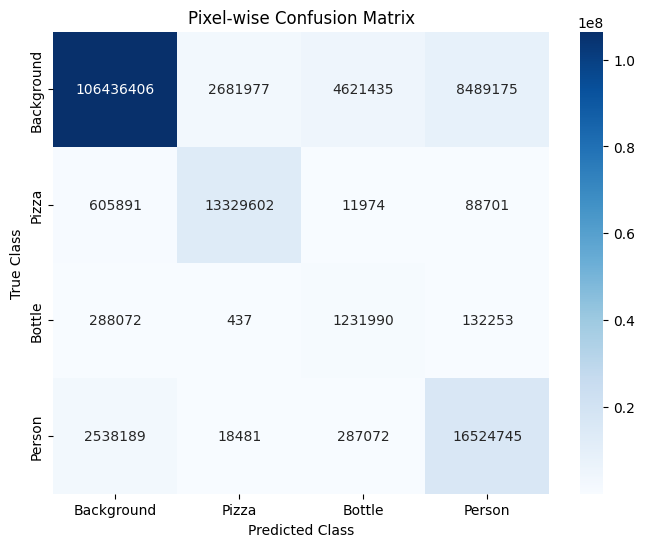

In [ ]:
class_names = ['Background', 'Pizza', 'Bottle', 'Person']

print("\n--- PIXEL-WISE CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\n[INFO] Generating Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Pixel-wise Confusion Matrix')
plt.show()

In [ ]:
target_classes = {1: 'Pizza', 2: 'Bottle', 3: 'Person'}
found_samples = {} # Will hold {class_id: (image_tensor, mask_tensor)}

# The Scout Loop: Scan the dataloader until we find one of each class
for images, masks in test_loader:
    # Iterate through the images in the current batch
    for i in range(images.size(0)):
        # What classes are actually inside this specific image's mask?
        unique_classes_in_image = torch.unique(masks[i]).tolist()

        for class_id, class_name in target_classes.items():
            # If the class is in the image, and we haven't found a sample for it yet
            if class_id in unique_classes_in_image and class_id not in found_samples:
                found_samples[class_id] = (images[i], masks[i])
                print(f" -> Found a great sample for: {class_name}")

        # If we have collected all 3 classes, we can stop scanning
        if len(found_samples) == len(target_classes):
            break

    if len(found_samples) == len(target_classes):
        break

print("\n[INFO] Generating Entropy Heatmaps for selected samples...")

for class_id, (img_tensor, true_mask_tensor) in found_samples.items():
    class_name = target_classes[class_id]

    # Move to GPU for fast inference
    img_tensor = img_tensor.cuda()
    true_mask = true_mask_tensor.numpy()

    with torch.no_grad():
        logits = loaded_model(img_tensor.unsqueeze(0))
        probs = F.softmax(logits, dim=1)[0]
        pred_mask = torch.argmax(probs, dim=0).cpu().numpy()

        # Calculate Shannon Entropy: H = -sum(P * log(P))
        entropy = -torch.sum(probs * torch.log(probs + 1e-7), dim=0).cpu().numpy()

    # Convert image back to displayable RGB format
    img_display = img_tensor.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    # Plotting the visualization
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"Activation Map & Entropy Analysis: {class_name}", fontsize=16, fontweight='bold', y=1.05)

    axes[0].imshow(img_display)
    axes[0].set_title("Original Test Image")
    axes[0].axis('off')

    axes[1].imshow(true_mask, cmap='nipy_spectral', vmin=0, vmax=3)
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis('off')

    axes[2].imshow(pred_mask, cmap='nipy_spectral', vmin=0, vmax=3)
    axes[2].set_title("U-Net Prediction")
    axes[2].axis('off')

    # The Entropy Heatmap (Hot colors = confused pixels)
    im3 = axes[3].imshow(entropy, cmap='inferno')
    axes[3].set_title("Uncertainty Heatmap (Entropy)")
    axes[3].axis('off')
    fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Testing trained model on 100 unseen images from OpenImages dataset

In [ ]:
!pip install -q fiftyone

In [ ]:
import fiftyone as fo
import fiftyone.zoo as foz

In [ ]:
DRIVE_VAL_DIR = '/content/drive/MyDrive/SegmentationProject/semantic_masks/val'
is_mounted = safe_mount_drive(sanity_check_path=DRIVE_VAL_DIR)

[INFO] Initiating safe Google Drive mount sequence...
[INFO] Flushing existing connections...
Drive not mounted, so nothing to flush and unmount.
[INFO] Mounting Google Drive...
Mounted at /content/drive

[SUCCESS] Mount verified! Found 600 items at: /content/drive/MyDrive/SegmentationProject/semantic_masks/val


In [ ]:
CLASS_MAP = {
    "Pizza": 1,
    "Bottle": 2,
    "Person": 3
}

TEST_DIR = '/content/drive/MyDrive/SegmentationProject/openimages_test'
IMG_DIR = os.path.join(TEST_DIR, 'images')
MASK_DIR = os.path.join(TEST_DIR, 'masks')

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

print("[INFO] Downloading 100 images and masks...")
dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="test",
    label_types=["segmentations"],
    classes=list(CLASS_MAP.keys()),
    max_samples=100,
    dataset_name="openimages-test-100"
)

print(f"\n[INFO] Download complete! Processing {len(dataset)} samples...")

for sample in dataset:
    orig_img_path = sample.filepath
    img_filename = os.path.basename(orig_img_path)
    base_name = os.path.splitext(img_filename)[0]

    img = Image.open(orig_img_path).convert("RGB")
    width, height = img.size

    semantic_mask = np.zeros((height, width), dtype=np.uint8)

    labels = None
    if sample.has_field("segmentations"):
        labels = sample.segmentations
    elif sample.has_field("ground_truth"):
        labels = sample.ground_truth

    if labels is not None and hasattr(labels, "detections") and labels.detections is not None:
        for detection in labels.detections:
            label_name = detection.label

            if label_name in CLASS_MAP:
                class_id = CLASS_MAP[label_name]

                mask = detection.mask
                if mask is not None:
                    x, y, w, h = detection.bounding_box
                    abs_x = int(x * width)
                    abs_y = int(y * height)
                    abs_w = int(w * width)
                    abs_h = int(h * height)

                    if abs_w == 0 or abs_h == 0:
                        continue

                    end_x = min(abs_x + abs_w, width)
                    end_y = min(abs_y + abs_h, height)

                    actual_w = end_x - abs_x
                    actual_h = end_y - abs_y

                    mask_img = Image.fromarray(mask)
                    mask_resized = np.array(mask_img.resize((abs_w, abs_h), Image.NEAREST))
                    mask_cropped = mask_resized[:actual_h, :actual_w]

                    semantic_mask[abs_y:end_y, abs_x:end_x][mask_cropped] = class_id

    save_img_path = os.path.join(IMG_DIR, f"{base_name}.jpg")
    save_mask_path = os.path.join(MASK_DIR, f"{base_name}.png")

    img.save(save_img_path)
    Image.fromarray(semantic_mask).save(save_mask_path)

print(f"[INFO] Success! Test set saved to: {TEST_DIR}")

[INFO] Downloading 100 images and masks...


INFO:fiftyone.zoo.datasets:Downloading split 'test' to '/root/fiftyone/open-images-v7/test' if necessary


Necessary images already downloaded


INFO:fiftyone.utils.openimages:Necessary images already downloaded


Existing download of split 'test' is sufficient


INFO:fiftyone.zoo.datasets:Existing download of split 'test' is sufficient


Loading existing dataset 'openimages-test-100'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


INFO:fiftyone.zoo.datasets:Loading existing dataset 'openimages-test-100'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use



[INFO] Download complete! Processing 100 samples...
[INFO] Success! Test set saved to: /content/drive/MyDrive/SegmentationProject/openimages_test


In [ ]:
!cp -r /content/drive/MyDrive/SegmentationProject/openimages_test /content/openimages_test_local

In [ ]:
LOCAL_TEST_DIR = '/content/openimages_test_local'
IMG_DIR = os.path.join(LOCAL_TEST_DIR, 'images')
MASK_DIR = os.path.join(LOCAL_TEST_DIR, 'masks')

IMAGE_SIZE = 512

# Same validation transforms used during training
test_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

all_preds = []
all_trues = []

# Ensure model is on GPU and in evaluation mode
loaded_model.cuda()
loaded_model.eval()

print(f"[INFO] Running U-Net Inference on 100 Unseen OpenImages ({IMAGE_SIZE}x{IMAGE_SIZE})...")

image_files = [f for f in os.listdir(IMG_DIR) if f.endswith('.jpg')]

with torch.no_grad():
    for img_name in tqdm(image_files):
        img_path = os.path.join(IMG_DIR, img_name)
        mask_path = os.path.join(MASK_DIR, img_name.replace('.jpg', '.png'))

        # Load Image and True Mask
        image = np.array(Image.open(img_path).convert("RGB"))
        true_mask = np.array(Image.open(mask_path))

        # Apply transforms (resizes image to 512x512 and converts to tensor)
        transformed = test_transform(image=image)
        img_tensor = transformed['image'].unsqueeze(0).cuda()

        # Run U-Net Forward Pass
        logits = loaded_model(img_tensor)

        # Get predictions (shape: [512, 512])
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

        # The true mask is still its original size so we must resize the prediction
        # back to the original image dimensions to do a mathematically fair pixel comparison.
        orig_height, orig_width = true_mask.shape
        pred_mask_resized = np.array(Image.fromarray(pred_mask).resize(
            (orig_width, orig_height), resample=Image.NEAREST
        ))

        # Flatten arrays for sklearn report
        all_preds.append(pred_mask_resized.flatten())
        all_trues.append(true_mask.flatten())

# Concatenate all lists into giant 1D numpy arrays
flat_preds = np.concatenate(all_preds)
flat_trues = np.concatenate(all_trues)

[INFO] Running U-Net Inference on 100 Unseen OpenImages (512x512)...


  0%|          | 0/100 [00:00<?, ?it/s]


--- PIXEL-WISE CLASSIFICATION REPORT (OPENIMAGES) ---
              precision    recall  f1-score   support

  Background       0.94      0.83      0.88  63943750
       Pizza       0.84      0.95      0.89   4177588
      Bottle       0.56      0.60      0.58   6686200
      Person       0.17      0.70      0.27   2122510

    accuracy                           0.81  76930048
   macro avg       0.63      0.77      0.66  76930048
weighted avg       0.88      0.81      0.84  76930048


[INFO] Generating Confusion Matrix...


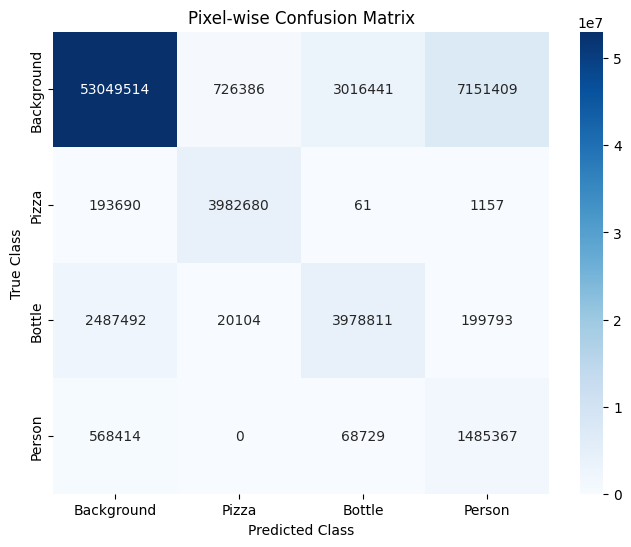

In [ ]:
print("\n" + "="*50)
print("--- PIXEL-WISE CLASSIFICATION REPORT (OPENIMAGES) ---")
print("="*50)
print(classification_report(
    flat_trues,
    flat_preds,
    target_names=class_names,
    labels=[0, 1, 2, 3],
    zero_division=0
))

print("\n[INFO] Generating Confusion Matrix...")
cm = confusion_matrix(flat_trues, flat_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Pixel-wise Confusion Matrix')
plt.show()

In [ ]:
target_classes = {1: 'Pizza', 2: 'Bottle', 3: 'Person'}
found_samples = {} # Will hold {class_id: filename}

test_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

loaded_model.cuda()
loaded_model.eval()

print("[INFO] Scouting for the best samples of each class...")
image_files = [f for f in os.listdir(IMG_DIR) if f.endswith('.jpg')]

for filename in image_files:
    # We only need to load the mask to check what classes are inside
    mask_path = os.path.join(MASK_DIR, filename.replace('.jpg', '.png'))
    true_mask = np.array(Image.open(mask_path))
    unique_classes_in_image = np.unique(true_mask).tolist()

    for class_id, class_name in target_classes.items():
        if class_id in unique_classes_in_image and class_id not in found_samples:
            found_samples[class_id] = filename
            print(f" -> Found a great sample for: {class_name} ({filename})")

    # If we have collected all 3 classes, we can stop scanning
    if len(found_samples) == len(target_classes):
        break

print("\n[INFO] Generating Entropy Heatmaps for selected samples...")

for class_id, filename in found_samples.items():
    class_name = target_classes[class_id]

    img_path = os.path.join(IMG_DIR, filename)
    mask_path = os.path.join(MASK_DIR, filename.replace('.jpg', '.png'))

    image_pil = Image.open(img_path).convert("RGB")
    true_mask = np.array(Image.open(mask_path))
    orig_width, orig_height = image_pil.size

    # Transform to 512x512 for the model
    transformed = test_transform(image=np.array(image_pil))
    img_tensor = transformed['image'].unsqueeze(0).cuda()

    # Forward Pass
    with torch.no_grad():
        logits = loaded_model(img_tensor)
        probs = F.softmax(logits, dim=1)

        pred_mask_512 = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

        epsilon = 1e-10
        entropy_512 = -torch.sum(probs * torch.log2(probs + epsilon), dim=1).squeeze(0).cpu().numpy()

    # Resize predictions back to original resolution
    pred_mask_resized = np.array(Image.fromarray(pred_mask_512).resize((orig_width, orig_height), Image.NEAREST))
    entropy_resized = np.array(Image.fromarray(entropy_512).resize((orig_width, orig_height), Image.BILINEAR))

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    fig.suptitle(f"Activation Map & Entropy Analysis: {class_name}", fontsize=18, fontweight='bold', y=1.05)

    axes[0].imshow(image_pil)
    axes[0].set_title("Original Test Image", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(true_mask, cmap='viridis', vmin=0, vmax=3)
    axes[1].set_title("Ground Truth Mask", fontsize=14)
    axes[1].axis('off')

    axes[2].imshow(pred_mask_resized, cmap='viridis', vmin=0, vmax=3)
    axes[2].set_title("U-Net Prediction", fontsize=14)
    axes[2].axis('off')

    im3 = axes[3].imshow(entropy_resized, cmap='inferno', vmin=0, vmax=2.0)
    axes[3].set_title("Uncertainty Heatmap (Entropy)", fontsize=14)
    axes[3].axis('off')
    fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Comparing U-Net vs. SAM 1 (ViT-Base) model

### Approach: Zero-Shot Benchmarking (U-Net vs. SAM)

To evaluate the efficacy of our specialized model, we benchmarked it against **Meta's Segment Anything Model (SAM)** combined with **GroundingDINO** (Grounded-SAM).

**1. Specialized vs. Generalized Models**
*   **U-Net (Specialized):** Trained specifically on our subset of classes. It is expected to be significantly faster and more consistent on the specific domain (Restaurant/Food scenes).
*   **SAM (Generalized):** A massive foundation model with zero-shot capabilities. It has broad knowledge but requires significantly more compute.

**2. Metrics for Comparison**
*   **Inference Speed:** Measured in seconds per image to highlight the deployment feasibility of the U-Net.
*   **F1-Score:** Used to evaluate the balance between Precision and Recall across the different classes on the unseen OpenImages test set.

Using a text-to-bounding-box model (GroundingDINO) as a middleman. We prompt SAM with our classes and it uses its generalized knowledge to cut it out.

In [ ]:
ckpt_path = '/content/drive/MyDrive/SegmentationProject/checkpoints/unet-best-epoch=54-val_f1=0.72.ckpt'

# Load the model directly from the checkpoint
loaded_model = SegmentationSystem.load_from_checkpoint(
    ckpt_path,
    model=model,
    num_classes=4
)
loaded_model.eval()
loaded_model.cuda()

In [ ]:
!pip install -q autodistill-grounded-sam roboflow supervision

In [ ]:
!pip install -q transformers==4.39.3

In [ ]:
from autodistill_grounded_sam import GroundedSAM
from autodistill.detection import CaptionOntology
from torchmetrics.classification import MulticlassF1Score

In [ ]:
# The ontology automatically maps text to IDs: 0, 1, 2
ontology = CaptionOntology({
    "pizza": "pizza",
    "bottle": "bottle",
    "person": "person"
})
sam_model = GroundedSAM(ontology=ontology)

IMAGE_SIZE = 512
TEST_IMAGES_DIR = '/content/openimages_test_local/images'
TEST_MASKS_DIR = '/content/openimages_test_local/masks'

test_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print(f"[INFO] Starting Benchmark on 100 images (U-Net Resolution: {IMAGE_SIZE}x{IMAGE_SIZE})...")

sam_inference_times = []
unet_inference_times = []
all_sam_preds = []
all_true_masks = []
all_unet_preds = []

loaded_model.cuda()
loaded_model.eval()

image_files = [f for f in os.listdir(TEST_IMAGES_DIR) if f.endswith('.jpg')]

for filename in image_files:
    img_path = os.path.join(TEST_IMAGES_DIR, filename)
    mask_path = os.path.join(TEST_MASKS_DIR, filename.replace('.jpg', '.png'))

    image_pil = Image.open(img_path).convert("RGB")
    orig_width, orig_height = image_pil.size

    true_mask = np.array(Image.open(mask_path))
    all_true_masks.append(true_mask.flatten())

    start_time = time.time()

    # Autodistill takes the file path directly!
    results = sam_model.predict(img_path)

    sam_combined_mask = np.zeros((orig_height, orig_width), dtype=np.uint8)

    # Autodistill safely returns masks and class_ids (0=pizza, 1=bottle, 2=person)
    if results.mask is not None:
        for mask, class_id in zip(results.mask, results.class_id):
            mapped_id = class_id + 1  # Shift up to match your 1, 2, 3 system
            sam_combined_mask[mask] = mapped_id

    sam_inference_times.append(time.time() - start_time)
    all_sam_preds.append(sam_combined_mask.flatten())

    transformed = test_transform(image=np.array(image_pil))
    img_tensor = transformed['image'].unsqueeze(0).cuda()

    start_time = time.time()
    with torch.no_grad():
        logits = loaded_model(img_tensor)
        unet_pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    unet_inference_times.append(time.time() - start_time)

    unet_pred_resized = np.array(Image.fromarray(unet_pred_mask).resize((orig_width, orig_height), Image.NEAREST))
    all_unet_preds.append(unet_pred_resized.flatten())

trying to load grounding dino directly


torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)


final text_encoder_type: bert-base-uncased


`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.


[INFO] Starting Benchmark on 100 images (U-Net Resolution: 512x512)...


The `device` argument is deprecated and will be removed in v5 of Transformers.
torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
None of the inputs have requires_grad=True. Gradients will be None
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


In [ ]:
flat_true = torch.tensor(np.concatenate(all_true_masks))
flat_sam = torch.tensor(np.concatenate(all_sam_preds))
flat_unet = torch.tensor(np.concatenate(all_unet_preds))

f1_metric = MulticlassF1Score(num_classes=4, average='none')

sam_f1_scores = f1_metric(flat_sam, flat_true).numpy()
unet_f1_scores = f1_metric(flat_unet, flat_true).numpy()

avg_sam_time = np.mean(sam_inference_times)
avg_unet_time = np.mean(unet_inference_times)

print("\n" + "="*50)
print("             FINAL BENCHMARK REPORT               ")
print("==================================================")
print(f"Average Inference Speed:")
print(f"  -> Your U-Net (512): {avg_unet_time:.4f} seconds/image")
print(f"  -> Meta SAM:         {avg_sam_time:.4f} seconds/image")
print(f"  *(Your model is {avg_sam_time/avg_unet_time:.1f}x faster)*\n")

print("F1 Scores (Class 1: Pizza, Class 2: Bottle, Class 3: Person):")
print(f"  -> Meta SAM:   {sam_f1_scores[1:]}")
print(f"  -> Your U-Net: {unet_f1_scores[1:]}")
print("==================================================")


             FINAL BENCHMARK REPORT               
Average Inference Speed:
  -> Your U-Net (512): 0.0101 seconds/image
  -> Meta SAM:         1.1337 seconds/image
  *(Your model is 112.3x faster)*

F1 Scores (Class 1: Pizza, Class 2: Bottle, Class 3: Person):
  -> Meta SAM:   [0.46361372 0.8440132  0.31058267]
  -> Your U-Net: [0.8943052  0.57872593 0.27104655]



--- PIXEL-WISE CLASSIFICATION REPORT (META SAM) ---
              precision    recall  f1-score   support

  Background       0.99      0.89      0.94  63943750
       Pizza       0.71      0.34      0.46   4177588
      Bottle       0.82      0.87      0.84   6686200
      Person       0.19      0.92      0.31   2122510

    accuracy                           0.86  76930048
   macro avg       0.68      0.76      0.64  76930048
weighted avg       0.94      0.86      0.89  76930048


[INFO] Generating Confusion Matrix...


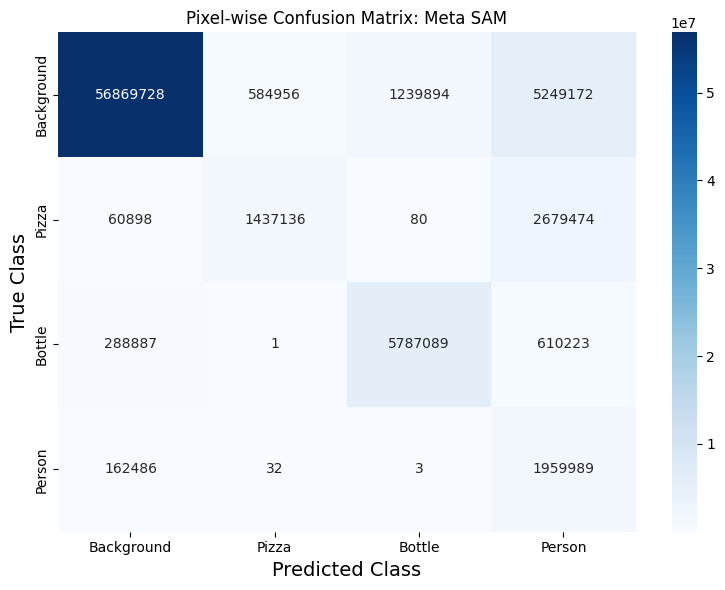

In [ ]:
y_true = flat_true.numpy()
y_pred_sam = flat_sam.numpy()

target_names = ['Background', 'Pizza', 'Bottle', 'Person']

print("\n" + "="*50)
print("--- PIXEL-WISE CLASSIFICATION REPORT (META SAM) ---")
print("="*50)
print(classification_report(
    y_true,
    y_pred_sam,
    target_names=target_names,
    labels=[0, 1, 2, 3],
    zero_division=0
))

print("\n[INFO] Generating Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred_sam, labels=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)

plt.title('Pixel-wise Confusion Matrix: Meta SAM')
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.tight_layout()
plt.show()